In [2]:
# Célula 1: imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import (
    KFold, StratifiedKFold, LeaveOneOut, cross_validate, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)

# 1. RandomForestClassifier

In [ ]:
# Célula 2: configurações
CSV_PATH = "abalone_dataset.csv"   # ajuste o caminho
RANDOM_STATE = 42

N_ESTIMATORS = 200         # árvores nos K-Folds
K_LIST = [3, 5, 10, 20]

REMOVER_SOMA_INVALIDA = False  # True: remove linhas com shucked+viscera+shell > whole
TOL = 1e-9                     # tolerância para erro de ponto flutuante

LOO_AMOSTRA = None  # None = LOO completo; ex.: 500 = teste rápido com 500 linhas

In [4]:
# Célula 3: carregar dados
df = pd.read_csv(CSV_PATH)
print(df.shape)
print(df["type"].value_counts().sort_index())

X = df.drop(columns="type")
y = df["type"]
cat_cols = ["sex"]

(3132, 9)
type
1    1078
2    1003
3    1051
Name: count, dtype: int64


In [5]:
# Célula 4: modelo (pipeline evita vazamento: o one-hot é ajustado só no treino de cada fold)
def make_model(n_estimators, n_jobs=-1):
    pre = ColumnTransformer(
        [("sex", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
        remainder="passthrough",
    )
    rf = RandomForestClassifier(
        n_estimators=n_estimators, random_state=RANDOM_STATE, n_jobs=n_jobs
    )
    return Pipeline([("pre", pre), ("rf", rf)])

In [6]:
# Célula 5: KFold e StratifiedKFold com vários K
scoring = {"acc": "accuracy", "f1_macro": "f1_macro"}
rows = []

for nome, Splitter in [("KFold", KFold), ("StratifiedKFold", StratifiedKFold)]:
    for k in K_LIST:
        cv = Splitter(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
        t0 = time.time()
        res = cross_validate(make_model(N_ESTIMATORS), X, y, cv=cv, scoring=scoring, n_jobs=1)
        rows.append({
            "validacao": nome, "K": k,
            "acc_media": res["test_acc"].mean(), "acc_std": res["test_acc"].std(),
            "f1_macro_media": res["test_f1_macro"].mean(),
            "f1_macro_std": res["test_f1_macro"].std(),
            "tempo_s": time.time() - t0,
        })
        r = rows[-1]
        print(f"{nome:16s} K={k:<3d} acc={r['acc_media']:.4f} ± {r['acc_std']:.4f} "
              f"| f1_macro={r['f1_macro_media']:.4f}")

df_kfold = pd.DataFrame(rows)
df_kfold.round(4)

KFold            K=3   acc=0.6450 ± 0.0103 | f1_macro=0.6427
KFold            K=5   acc=0.6421 ± 0.0057 | f1_macro=0.6381
KFold            K=10  acc=0.6475 ± 0.0140 | f1_macro=0.6427
KFold            K=20  acc=0.6379 ± 0.0264 | f1_macro=0.6320
StratifiedKFold  K=3   acc=0.6491 ± 0.0066 | f1_macro=0.6456
StratifiedKFold  K=5   acc=0.6520 ± 0.0203 | f1_macro=0.6478
StratifiedKFold  K=10  acc=0.6510 ± 0.0269 | f1_macro=0.6475
StratifiedKFold  K=20  acc=0.6469 ± 0.0369 | f1_macro=0.6419


,validacao,K,acc_media,acc_std,f1_macro_media,f1_macro_std,tempo_s
0,KFold,3,0.6450,0.0103,0.6427,0.0109,1.0739
1,KFold,5,0.6421,0.0057,0.6381,0.0080,1.6710
2,KFold,10,0.6475,0.0140,0.6427,0.0140,3.3543
3,KFold,20,0.6379,0.0264,0.6320,0.0273,6.4627
4,StratifiedKFold,3,0.6491,0.0066,0.6456,0.0092,0.9552
5,StratifiedKFold,5,0.6520,0.0203,0.6478,0.0227,1.6986
6,StratifiedKFold,10,0.6510,0.0269,0.6475,0.0276,3.3050
7,StratifiedKFold,20,0.6469,0.0369,0.6419,0.0370,6.5206


In [7]:
# Célula 7: tabela comparativa
loo_row = pd.DataFrame([{
    "validacao": "LeaveOneOut", "K": len(X_loo),
    "acc_media": acc_loo, "acc_std": np.nan,
    "f1_macro_media": f1_loo, "f1_macro_std": np.nan, "tempo_s": tempo_loo,
}])
df_all = pd.concat([df_kfold, loo_row], ignore_index=True)
df_all.round(4)

NameError: name 'X_loo' is not defined

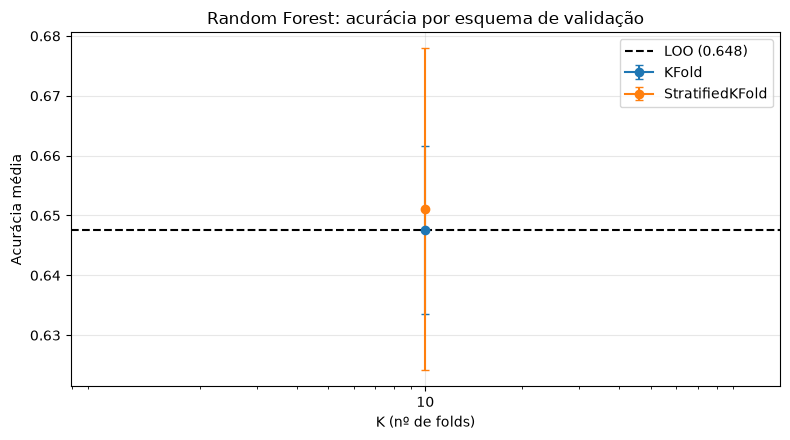

In [ ]:
# Célula 8: gráfico
fig, ax = plt.subplots(figsize=(8, 4.5))
for nome, g in df_kfold.groupby("validacao"):
    ax.errorbar(g["K"], g["acc_media"], yerr=g["acc_std"],
                marker="o", capsize=3, label=nome)
ax.axhline(acc_loo, color="k", ls="--", label=f"LOO ({acc_loo:.3f})")
ax.set_xscale("log")
ax.set_xticks(K_LIST)
ax.set_xticklabels(K_LIST)
ax.set_xlabel("K (nº de folds)")
ax.set_ylabel("Acurácia média")
ax.set_title("Random Forest: acurácia por esquema de validação")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

--- KFold K=10 ---
              precision    recall  f1-score   support

           1      0.753     0.751     0.752      1078
           2      0.510     0.501     0.506      1003
           3      0.668     0.680     0.674      1051

    accuracy                          0.648      3132
   macro avg      0.644     0.644     0.644      3132
weighted avg      0.647     0.648     0.647      3132

--- StratifiedKFold K=10 ---
              precision    recall  f1-score   support

           1      0.767     0.760     0.763      1078
           2      0.515     0.516     0.516      1003
           3      0.663     0.668     0.665      1051

    accuracy                          0.651      3132
   macro avg      0.648     0.648     0.648      3132
weighted avg      0.651     0.651     0.651      3132



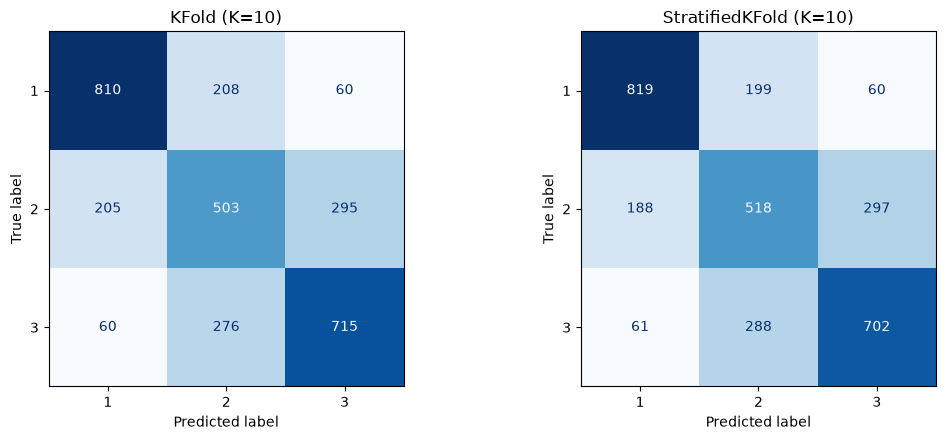

In [ ]:
# Célula 10: KFold e StratifiedKFold com K=10 (matriz de confusão lado a lado)
K_ESCOLHIDO = 10
splitters = [("KFold", KFold), ("StratifiedKFold", StratifiedKFold)]
preds = {}

fig, axes = plt.subplots(1, len(splitters), figsize=(11, 4.5))

for ax, (nome, Splitter) in zip(axes, splitters):
    cv = Splitter(n_splits=K_ESCOLHIDO, shuffle=True, random_state=RANDOM_STATE)
    y_pred = cross_val_predict(make_model(N_ESTIMATORS), X, y, cv=cv, n_jobs=1)
    preds[nome] = y_pred

    print(f"--- {nome} K={K_ESCOLHIDO} ---")
    print(classification_report(y, y_pred, digits=3))

    ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{nome} (K={K_ESCOLHIDO})")

plt.tight_layout()
plt.show()

In [ ]:
# Célula 12: normalização dentro do pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

num_cols = [c for c in X.columns if c not in cat_cols]

def make_pipeline_scaled(classificador, scaler=None):
    """Pré-processamento: one-hot em 'sex' + normalização das numéricas (opcional)."""
    pre = ColumnTransformer([
        ("sex", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", scaler if scaler is not None else "passthrough", num_cols),
    ])
    return Pipeline([("pre", pre), ("clf", classificador)])

,classificador,normalização,acc_media,acc_std,f1_macro_media
0,LogisticRegression,sem normalização,0.6414,0.0134,0.6341
1,LogisticRegression,StandardScaler,0.6529,0.0232,0.6497
2,LogisticRegression,MinMaxScaler,0.6370,0.0105,0.6292
3,LogisticRegression,RobustScaler,0.6507,0.0191,0.6470
4,SVC (RBF),sem normalização,0.6376,0.0236,0.6375
5,SVC (RBF),StandardScaler,0.6663,0.0163,0.6634
6,SVC (RBF),MinMaxScaler,0.6264,0.0205,0.6273
7,SVC (RBF),RobustScaler,0.6609,0.0142,0.6585
8,KNN,sem normalização,0.6290,0.0155,0.6250
9,KNN,StandardScaler,0.6207,0.0269,0.6159


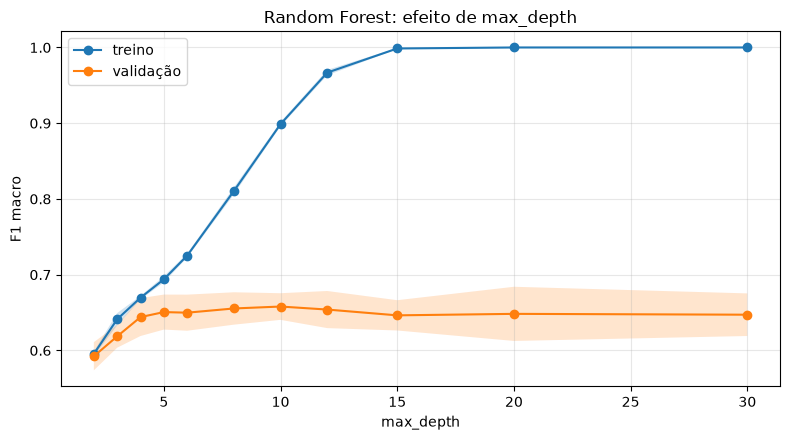

In [ ]:
# Célula 17: curva de validação para max_depth
from sklearn.model_selection import validation_curve

profundidades = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]
# None não funciona bem como valor numérico no gráfico; usamos 30 como "sem limite" aproximado
valores = [d if d is not None else 30 for d in profundidades]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

train_scores, val_scores = validation_curve(
    make_model(N_ESTIMATORS), X, y,
    param_name="rf__max_depth", param_range=valores,
    cv=cv, scoring="f1_macro", n_jobs=1,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for scores, nome in [(train_scores, "treino"), (val_scores, "validação")]:
    m, s = scores.mean(axis=1), scores.std(axis=1)
    ax.plot(valores, m, marker="o", label=nome)
    ax.fill_between(valores, m - s, m + s, alpha=.2)
ax.set_xlabel("max_depth")
ax.set_ylabel("F1 macro")
ax.set_title("Random Forest: efeito de max_depth")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()